In [4]:
!pip install alpaca-trade-api
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from alpaca_trade_api.rest import REST, TimeFrame
from datetime import datetime, timedelta
import scipy.optimize as sco
import scipy.stats as stats

In [5]:
# 1. Configuración de API de Alpaca
# Reemplaza con tus credenciales de paper trading
API_KEY = 'PK3YUI7JLFQFSPG25STNLEZNES'
SECRET_KEY = 'HeMC4cxcg8XHvSy34T5Yk8mWZ3xJV4LXRkPiSvYJEPCw'
BASE_URL = 'https://paper-api.alpaca.markets'

api = REST(API_KEY, SECRET_KEY, BASE_URL, api_version='v2')

In [6]:
# 2. Los 20 activos seleccionados para el portafolio institucional
tickers = [
    # Bloque Transatlántico (Europa y Salud)
    'ASML', 'SAP', 'LVMUY', 'NVS', 'AZN',

    # Bloque Asia-Pacífico y Ciclo (Japón)
    'SONY', 'MUFG', 'MFG', 'HMC',

    # Bloque USA y Activos Reales (Growth & Value)
    'EQIX', 'BRK.B', 'GS', 'XOM', 'O', 'AMT',

    # Bloque de Riesgo Sistémico (ETFs)
    'SPY', 'QQQ', 'VGK', 'EWJ', 'VWO'
]

In [7]:
# 3. Definir el periodo exacto de 5 años
end_date = datetime.today() - timedelta(days=8)
start_date = end_date - timedelta(days=5*365)

start_str = start_date.strftime('%Y-%m-%d')
end_str = end_date.strftime('%Y-%m-%d')

In [8]:
print(f"Extrayendo datos desde {start_str} hasta {end_str}...")

Extrayendo datos desde 2021-03-13 hasta 2026-03-12...


In [9]:
#4. Descarga de datos
# Se extraen las barras diarias y se convierten a DataFrame
bars = api.get_bars(tickers, TimeFrame.Day, start_str, end_str, adjustment='all').df
# Pivotar para tener solo los precios de cierre por ticker
precios_cierre = bars.pivot(columns='symbol', values='close')

# Limpieza de datos (por si algún activo tiene huecos o es más reciente)
precios_cierre = precios_cierre.ffill().dropna(axis=1)

In [10]:
# 5. CÁLCULO DE PARÁMETROS (Rendimientos Logarítmicos)
dias_bursatiles = 252

# Cálculo de los rendimientos logarítmicos diarios
rendimientos_diarios = np.log(precios_cierre / precios_cierre.shift(1)).dropna()

# Rendimientos esperados anualizados
rendimientos_esperados = rendimientos_diarios.mean() * dias_bursatiles

# Varianzas y Desviaciones Estándar Anualizadas
varianzas = rendimientos_diarios.var() * dias_bursatiles
desviaciones_estandar = rendimientos_diarios.std() * np.sqrt(dias_bursatiles)

# Matriz de Covarianzas Anualizada [cite: 20]
matriz_covarianzas = rendimientos_diarios.cov() * dias_bursatiles

# Matriz de Correlaciones [cite: 21]
matriz_correlaciones = rendimientos_diarios.corr()

Exportando resultados a Excel...
Archivo 'parametros_portafolio_20.xlsx' generado con éxito.
Generando gráficos de distribución de rendimientos...
Gráfico guardado exitosamente como 'distribuciones_20_activos.png'.


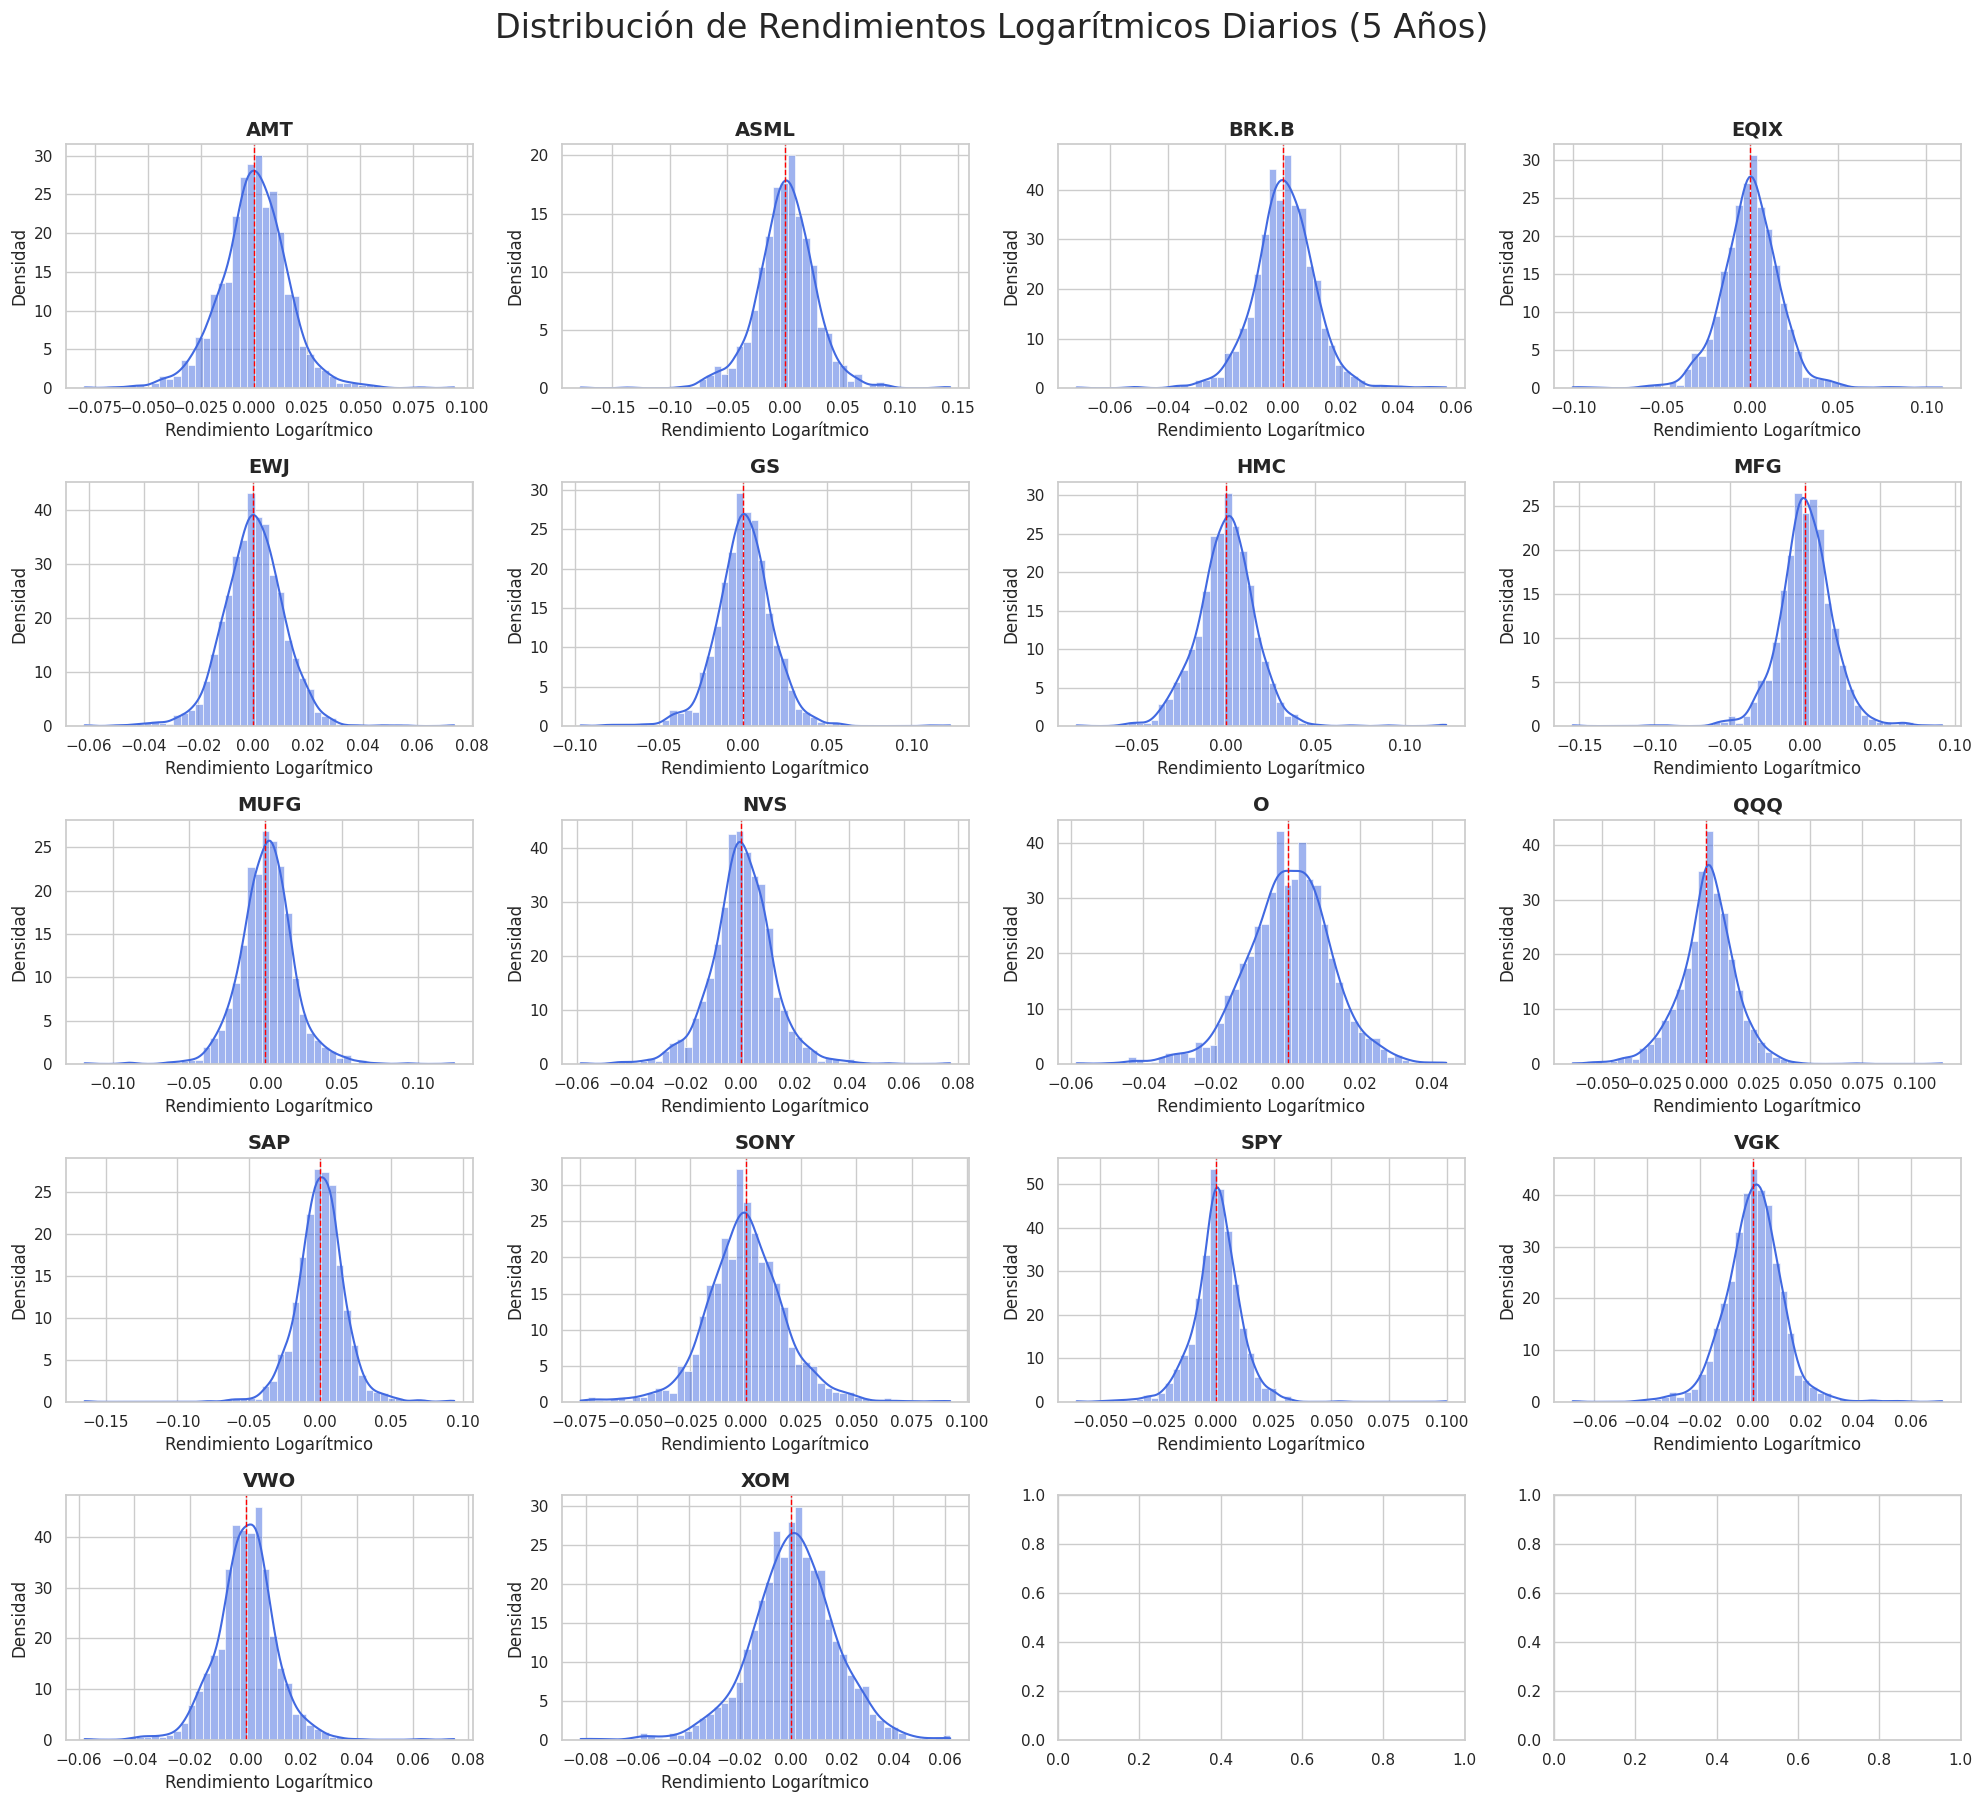

In [11]:
# 6. VISUALIZACIÓN Y EXPORTACIÓN DE RESULTADOS

print("Exportando resultados a Excel...")
# Usamos pd.ExcelWriter para guardar los datos en un solo archivo con múltiples pestañas
archivo_excel = 'parametros_portafolio_20.xlsx'
with pd.ExcelWriter(archivo_excel, engine='openpyxl') as writer:
    rendimientos_esperados.to_frame(name='Rendimiento_Anualizado').to_excel(writer, sheet_name='Rend_Esperados')
    desviaciones_estandar.to_frame(name='Volatilidad_Anualizada').to_excel(writer, sheet_name='Volatilidad')
    matriz_covarianzas.to_excel(writer, sheet_name='Matriz_Covarianzas')
    matriz_correlaciones.to_excel(writer, sheet_name='Matriz_Correlaciones')

print(f"Archivo '{archivo_excel}' generado con éxito.")

print("Generando gráficos de distribución de rendimientos...")
# Establecer el estilo de los gráficos
sns.set_theme(style="whitegrid")

# Crear una figura con subplots de 5 filas y 4 columnas (para los 20 activos)
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
fig.suptitle('Distribución de Rendimientos Logarítmicos Diarios (5 Años)', fontsize=24, y=0.92)

# Aplanar la matriz de ejes para iterar fácilmente
axes = axes.flatten()

# Iterar sobre cada activo para graficar su histograma y su curva de densidad (KDE)
for i, ticker in enumerate(rendimientos_diarios.columns):
    sns.histplot(rendimientos_diarios[ticker], bins=50, kde=True, ax=axes[i], color='royalblue', stat='density')
    axes[i].set_title(f'{ticker}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Rendimiento Logarítmico')
    axes[i].set_ylabel('Densidad')

    # Agregar una línea roja en el 0 para referencia visual
    axes[i].axvline(0, color='red', linestyle='--', linewidth=1)

# Ajustar el espaciado para que no se superpongan los títulos y etiquetas
plt.tight_layout(rect=[0, 0.02, 1, 0.90])

# Guardar la imagen en alta resolución
archivo_imagen = 'distribuciones_20_activos.png'
plt.savefig(archivo_imagen, dpi=300)
print(f"Gráfico guardado exitosamente como '{archivo_imagen}'.")

# plt.show() # Descomenta esta línea para verlo directamente en el Jupyter Notebook
#plt.show() # Descomenta esta línea si estás usando Jupyter Notebook y quieres verlo en pantalla

Simulando 30,000 portafolios factibles (Restricciones: Min 2.0%, Max 8.0%)...


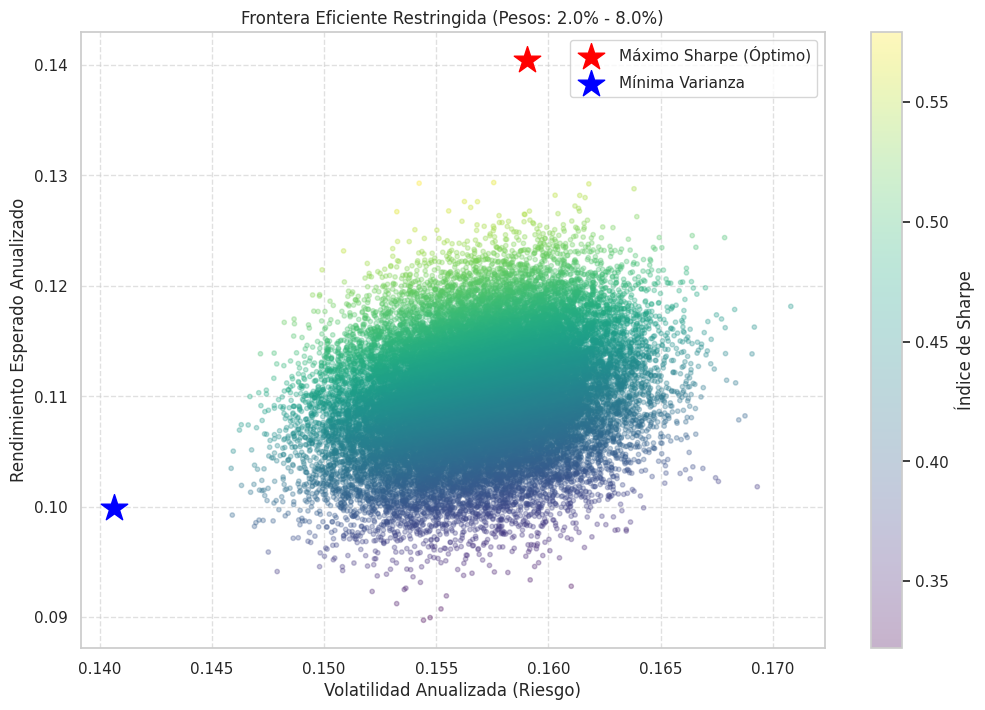


--- RESULTADOS DE LOS PORTAFOLIOS ÓPTIMOS (RESTRINGIDOS) ---
MÁXIMO SHARPE -> Rendimiento: 14.04% | Volatilidad: 15.90% | Sharpe: 0.63
MÍNIMA VARIANZA -> Rendimiento: 9.99% | Volatilidad: 14.07% | Sharpe: 0.43

Los pesos exactos para ambos portafolios han sido guardados en 'pesos_optimos_restringidos_20_activos.xlsx'.


In [12]:

# 7. ANÁLISIS MEDIA-VARIANZA Y FRONTERA EFICIENTE CON RESTRICCIONES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as sco

# Tasa libre de riesgo (usamos 4% o 0.04 como proxy de los Bonos del Tesoro de EE.UU.)
risk_free_rate = 0.04

# --- RESTRICCIONES DEL PORTAFOLIO ---
peso_min = 0.02 # 2% mínimo por activo
peso_max = 0.08 # 8% máximo por activo

# Funciones objetivo para la optimización matemática
def portfolio_annualised_performance(weights, mean_returns, cov_matrix):
    returns = np.sum(mean_returns * weights)
    std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return std, returns

def neg_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate):
    p_vol, p_ret = portfolio_annualised_performance(weights, mean_returns, cov_matrix)
    return -(p_ret - risk_free_rate) / p_vol

def portfolio_volatility(weights, mean_returns, cov_matrix):
    return portfolio_annualised_performance(weights, mean_returns, cov_matrix)[0]

# --- OPTIMIZACIÓN: PORTAFOLIO DE MÁXIMO SHARPE ---
def max_sharpe_ratio(mean_returns, cov_matrix, risk_free_rate):
    num_assets = len(mean_returns)
    args = (mean_returns, cov_matrix, risk_free_rate)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}) # La suma de los pesos es 1 (100%)

    # APLICAMOS RESTRICCIONES: Tupla con min y max para cada activo
    bounds = tuple((peso_min, peso_max) for asset in range(num_assets))

    result = sco.minimize(neg_sharpe_ratio, num_assets*[1./num_assets,], args=args,
                        method='SLSQP', bounds=bounds, constraints=constraints)
    return result

# --- OPTIMIZACIÓN: PORTAFOLIO DE MÍNIMA VARIANZA ---
def min_variance(mean_returns, cov_matrix):
    num_assets = len(mean_returns)
    args = (mean_returns, cov_matrix)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

    # APLICAMOS RESTRICCIONES: Tupla con min y max para cada activo
    bounds = tuple((peso_min, peso_max) for asset in range(num_assets))

    result = sco.minimize(portfolio_volatility, num_assets*[1./num_assets,], args=args,
                        method='SLSQP', bounds=bounds, constraints=constraints)
    return result

# Calculamos los dos portafolios óptimos
opt_sharpe = max_sharpe_ratio(rendimientos_esperados.values, matriz_covarianzas.values, risk_free_rate)
opt_min_vol = min_variance(rendimientos_esperados.values, matriz_covarianzas.values)

# Métricas de los portafolios óptimos
sdp_sharpe, rp_sharpe = portfolio_annualised_performance(opt_sharpe['x'], rendimientos_esperados.values, matriz_covarianzas.values)
sdp_min, rp_min = portfolio_annualised_performance(opt_min_vol['x'], rendimientos_esperados.values, matriz_covarianzas.values)

# --- SIMULACIÓN MONTE CARLO (Portafolios Factibles Restringidos) ---
num_portfolios = 30000
results = np.zeros((3, num_portfolios))

print(f"Simulando 30,000 portafolios factibles (Restricciones: Min {peso_min*100}%, Max {peso_max*100}%)...")
num_actual_assets = len(rendimientos_esperados)

for i in range(num_portfolios):
    # Generador de pesos válidos bajo las restricciones de 2% a 8%
    while True:
        weights = np.random.uniform(peso_min, peso_max, num_actual_assets)
        weights /= np.sum(weights) # Normalizar a 1
        # Comprobar si tras la normalización siguen dentro del rango
        if np.all(weights >= peso_min) and np.all(weights <= peso_max):
            break

    p_vol, p_ret = portfolio_annualised_performance(weights, rendimientos_esperados.values, matriz_covarianzas.values)
    results[0,i] = p_vol
    results[1,i] = p_ret
    results[2,i] = (p_ret - risk_free_rate) / p_vol # Sharpe Ratio

# --- VISUALIZACIÓN ---
plt.figure(figsize=(12, 8))
# Nube de Portafolios Factibles
plt.scatter(results[0,:], results[1,:], c=results[2,:], cmap='viridis', marker='o', s=10, alpha=0.3)
plt.colorbar(label='Índice de Sharpe')

# Marcador para Máximo Sharpe
plt.scatter(sdp_sharpe, rp_sharpe, marker='*', color='red', s=400, label='Máximo Sharpe (Óptimo)')
# Marcador para Mínima Varianza
plt.scatter(sdp_min, rp_min, marker='*', color='blue', s=400, label='Mínima Varianza')

plt.title(f'Frontera Eficiente Restringida (Pesos: {peso_min*100}% - {peso_max*100}%)')
plt.xlabel('Volatilidad Anualizada (Riesgo)')
plt.ylabel('Rendimiento Esperado Anualizado')
plt.legend(labelspacing=0.8)
plt.grid(True, linestyle='--', alpha=0.6)

archivo_frontera = 'frontera_eficiente_restringida_20_activos.png'
plt.savefig(archivo_frontera, dpi=300, bbox_inches='tight')
plt.show()

# --- EXPORTAR PESOS ÓPTIMOS A EXCEL ---
df_pesos = pd.DataFrame({
    'Min_Varianza': opt_min_vol['x'],
    'Max_Sharpe': opt_sharpe['x']
}, index=rendimientos_esperados.index).round(4)

df_pesos = df_pesos[df_pesos > 0.0001].fillna(0) # Limpiar ruido matemático de Scipy
archivo_pesos = 'pesos_optimos_restringidos_20_activos.xlsx'
df_pesos.to_excel(archivo_pesos)

print("\n--- RESULTADOS DE LOS PORTAFOLIOS ÓPTIMOS (RESTRINGIDOS) ---")
print(f"MÁXIMO SHARPE -> Rendimiento: {rp_sharpe*100:.2f}% | Volatilidad: {sdp_sharpe*100:.2f}% | Sharpe: {(rp_sharpe-risk_free_rate)/sdp_sharpe:.2f}")
print(f"MÍNIMA VARIANZA -> Rendimiento: {rp_min*100:.2f}% | Volatilidad: {sdp_min*100:.2f}% | Sharpe: {(rp_min-risk_free_rate)/sdp_min:.2f}")
print(f"\nLos pesos exactos para ambos portafolios han sido guardados en '{archivo_pesos}'.")

In [13]:
# 8. PRONÓSTICO Y VALUE AT RISK (VaR)

# 1. Definir variables iniciales
# Usaremos los pesos del portafolio de Máximo Sharpe para este análisis
pesos_optimos = opt_sharpe['x']
valor_portafolio = 1000000  # Asumimos una inversión inicial de $1,000,000 USD
dias_2_meses = 42
dias_3_meses = 63
nivel_confianza = 0.95

# --- SECCIÓN A: PRONÓSTICO A 2-3 MESES ---

# Rendimiento diario y volatilidad diaria del portafolio óptimo
rend_diario_port = np.sum((rendimientos_esperados.values / 252) * pesos_optimos)
vol_diaria_port = sdp_sharpe / np.sqrt(252)

# Pronóstico simple asumiendo una caminata aleatoria con deriva (Drift)
rend_esperado_2m = rend_diario_port * dias_2_meses
rend_esperado_3m = rend_diario_port * dias_3_meses

print("--- PRONÓSTICO DEL PORTAFOLIO DE MÁXIMO SHARPE ---")
print(f"Rendimiento esperado a 2 meses: {rend_esperado_2m*100:.2f}%")
print(f"Rendimiento esperado a 3 meses: {rend_esperado_3m*100:.2f}%\n")

# --- SECCIÓN B: CÁLCULO DEL VaR (Value at Risk) ---

print("--- ANÁLISIS DE RIESGO: VALUE AT RISK (VaR) ---")

# MÉTODO PARAMÉTRICO
# Encontramos el valor Z para el nivel de confianza del 95% y 99%
z_95 = stats.norm.ppf(1 - 0.05) # Para el 95% (cola izquierda)
z_99 = stats.norm.ppf(1 - 0.01) # Para el 99% (cola izquierda)

# VaR en Porcentaje (%)
var_param_95_1d_pct = abs(z_95) * vol_diaria_port
var_param_99_1d_pct = abs(z_99) * vol_diaria_port
var_param_95_3m_pct = var_param_95_1d_pct * np.sqrt(dias_3_meses)

# VaR en Valor Monetario ($)
var_param_95_1d = valor_portafolio * var_param_95_1d_pct
var_param_99_1d = valor_portafolio * var_param_99_1d_pct
var_param_95_3m = valor_portafolio * var_param_95_3m_pct

print("1. MÉTODO PARAMÉTRICO (Asumiendo Distribución Normal):")
print(f"VaR (95%, 1 día): ${var_param_95_1d:,.2f} ({var_param_95_1d_pct*100:.2f}%)")
print(f"VaR (99%, 1 día): ${var_param_99_1d:,.2f} ({var_param_99_1d_pct*100:.2f}%)")
print(f"VaR (95%, 3 meses): ${var_param_95_3m:,.2f} ({var_param_95_3m_pct*100:.2f}%) -> Máxima pérdida esperada en el horizonte.\n")


# MÉTODO HISTÓRICO
# Multiplicamos los rendimientos diarios históricos por los pesos óptimos
rend_historicos_portafolio = rendimientos_diarios.dot(pesos_optimos)

# VaR en Porcentaje (%) - Encontramos el percentil empírico
var_hist_95_1d_pct = abs(np.percentile(rend_historicos_portafolio, 5))
var_hist_99_1d_pct = abs(np.percentile(rend_historicos_portafolio, 1))
var_hist_95_3m_pct = var_hist_95_1d_pct * np.sqrt(dias_3_meses) # Escalado

# VaR en Valor Monetario ($)
var_hist_95_1d = valor_portafolio * var_hist_95_1d_pct
var_hist_99_1d = valor_portafolio * var_hist_99_1d_pct
var_hist_95_3m = valor_portafolio * var_hist_95_3m_pct

print("2. MÉTODO HISTÓRICO (Basado en datos reales de 5 años):")
print(f"VaR (95%, 1 día): ${var_hist_95_1d:,.2f} ({var_hist_95_1d_pct*100:.2f}%)")
print(f"VaR (99%, 1 día): ${var_hist_99_1d:,.2f} ({var_hist_99_1d_pct*100:.2f}%)")
print(f"VaR (95%, 3 meses): ${var_hist_95_3m:,.2f} ({var_hist_95_3m_pct*100:.2f}%)\n")

# Comparativa rápida con el SPY (Benchmark del último año)
# Asumimos que SPY está en la columna 'SPY' de tus datos
rend_spy_ultimo_anio = rendimientos_diarios['SPY'].tail(252).sum()
rend_port_ultimo_anio = rend_historicos_portafolio.tail(252).sum()

print("--- COMPARATIVA CONTRA BENCHMARK (ÚLTIMO AÑO) ---")
print(f"Rendimiento Portafolio Óptimo (Último Año): {rend_port_ultimo_anio*100:.2f}%")
print(f"Rendimiento SPY (Último Año): {rend_spy_ultimo_anio*100:.2f}%")

--- PRONÓSTICO DEL PORTAFOLIO DE MÁXIMO SHARPE ---
Rendimiento esperado a 2 meses: 2.34%
Rendimiento esperado a 3 meses: 3.51%

--- ANÁLISIS DE RIESGO: VALUE AT RISK (VaR) ---
1. MÉTODO PARAMÉTRICO (Asumiendo Distribución Normal):
VaR (95%, 1 día): $16,479.69 (1.65%)
VaR (99%, 1 día): $23,307.54 (2.33%)
VaR (95%, 3 meses): $130,803.46 (13.08%) -> Máxima pérdida esperada en el horizonte.

2. MÉTODO HISTÓRICO (Basado en datos reales de 5 años):
VaR (95%, 1 día): $15,122.99 (1.51%)
VaR (99%, 1 día): $25,479.13 (2.55%)
VaR (95%, 3 meses): $120,035.05 (12.00%)

--- COMPARATIVA CONTRA BENCHMARK (ÚLTIMO AÑO) ---
Rendimiento Portafolio Óptimo (Último Año): 26.02%
Rendimiento SPY (Último Año): 19.24%


In [14]:
# --- 9. DIMENSIONAMIENTO DE COBERTURA CAMBIARIA (HEDGING) ---

print("--- ESTRATEGIA DE MITIGACIÓN DE RIESGO CAMBIARIO ---")

# 1. Definir los activos por región/moneda base
activos_eur = ['ASML', 'SAP', 'LVMUY', 'NVS', 'AZN', 'VGK'] # Incluimos VGK (ETF Europeo)
activos_jpy = ['SONY', 'MUFG', 'MFG', 'HMC', 'EWJ'] # Incluimos EWJ (ETF Japonés)

# 2. Calcular el peso total de estas exposiciones en el Portafolio Óptimo (Máximo Sharpe)
peso_eur = sum([pesos_optimos[list(rendimientos_esperados.index).index(ticker)] for ticker in activos_eur if ticker in rendimientos_esperados.index])
peso_jpy = sum([pesos_optimos[list(rendimientos_esperados.index).index(ticker)] for ticker in activos_jpy if ticker in rendimientos_esperados.index])

# 3. Calcular el valor nocional a cubrir basado en el capital inicial ($1,000,000)
exposicion_eur_usd = valor_portafolio * peso_eur
exposicion_jpy_usd = valor_portafolio * peso_jpy

print(f"Exposición Total al EUR: {peso_eur*100:.2f}% del portafolio -> Nocional a cubrir: ${exposicion_eur_usd:,.2f} USD")
print(f"Exposición Total al JPY: {peso_jpy*100:.2f}% del portafolio -> Nocional a cubrir: ${exposicion_jpy_usd:,.2f} USD\n")

# 4. Parámetros teóricos para la cobertura
print(">> Ejecución Sugerida de Derivados:")
if exposicion_jpy_usd > 0:
    print(f"- FORWARD JPY/USD: Vender a plazo el equivalente a ${exposicion_jpy_usd:,.2f} USD en JPY para mitigar la caída del Yen.")

if exposicion_eur_usd > 0:
    print(f"- PUT OPTIONS EUR/USD: Comprar contratos Put (Plain Vanilla) por un nocional de ${exposicion_eur_usd:,.2f} USD.")
    print("  *Nota: La prima a pagar dependerá de la volatilidad implícita del EUR/USD (VIX cambiario) y el 'Moneyness' elegido (ej. At-The-Money).*")

--- ESTRATEGIA DE MITIGACIÓN DE RIESGO CAMBIARIO ---
Exposición Total al EUR: 20.23% del portafolio -> Nocional a cubrir: $202,342.96 USD
Exposición Total al JPY: 22.00% del portafolio -> Nocional a cubrir: $220,000.00 USD

>> Ejecución Sugerida de Derivados:
- FORWARD JPY/USD: Vender a plazo el equivalente a $220,000.00 USD en JPY para mitigar la caída del Yen.
- PUT OPTIONS EUR/USD: Comprar contratos Put (Plain Vanilla) por un nocional de $202,342.96 USD.
  *Nota: La prima a pagar dependerá de la volatilidad implícita del EUR/USD (VIX cambiario) y el 'Moneyness' elegido (ej. At-The-Money).*


--- IMPACTO DE LA COBERTURA EN EL VALUE AT RISK (VaR HISTÓRICO) ---
VaR Histórico ORIGINAL (95%, 1 día): $15,122.99 (1.51%)
VaR Histórico CUBIERTO (95%, 1 día): $12,864.88 (1.29%)

-> Reducción del Riesgo Diario: $2,258.11 USD
-> Nuevo VaR a 3 meses (95%): $102,111.82 (10.21%)


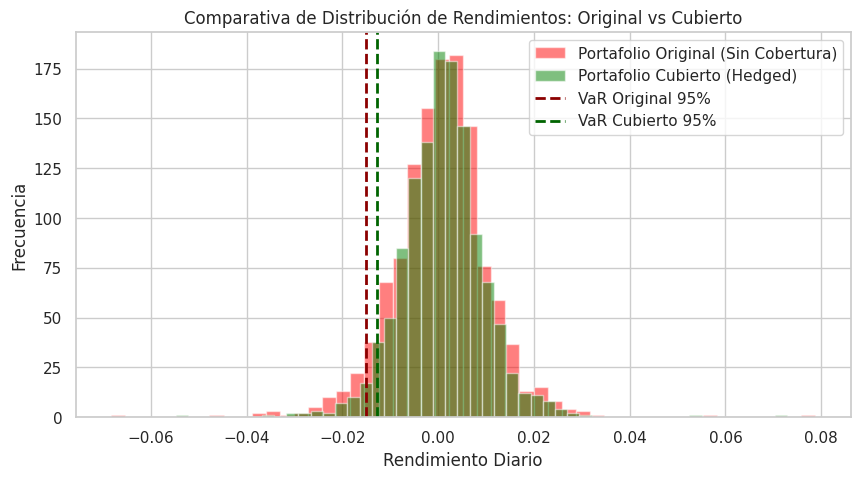

In [15]:
# --- 10. DEMOSTRACIÓN MATEMÁTICA: VaR HISTÓRICO CON COBERTURA (HEDGED VaR) ---

print("--- IMPACTO DE LA COBERTURA EN EL VALUE AT RISK (VaR HISTÓRICO) ---")

# 1. Creamos una copia de los rendimientos diarios para simular el portafolio cubierto
rendimientos_cubiertos = rendimientos_diarios.copy()

# --- SIMULACIÓN DE LA OPCIÓN PUT (Europa) ---
# Asumimos un "Strike" que limita la pérdida diaria máxima al -1.5% para los ADRs europeos.
# Es decir, si el activo cae un -4% por el desplome del Euro, la opción te compensa y tu pérdida se topa en -1.5%.
strike_put = -0.015
# La opción tiene un costo (prima) que se amortiza diariamente, reduciendo ligeramente el rendimiento bruto
costo_prima_diaria = 0.0001

for ticker in activos_eur:
    if ticker in rendimientos_cubiertos.columns:
        # np.maximum trunca la cola izquierda; luego restamos el costo del seguro
        rendimientos_cubiertos[ticker] = np.maximum(rendimientos_cubiertos[ticker], strike_put) - costo_prima_diaria

# --- SIMULACIÓN DEL FORWARD (Japón) ---
# Al fijar el tipo de cambio JPY/USD con un forward, eliminamos la volatilidad FX.
# Asumimos que el tipo de cambio aporta el 30% de la varianza diaria del ADR.
# Por tanto, multiplicamos los rendimientos diarios por 0.70 (reducción simétrica de volatilidad).
factor_reduccion_vol_fx = 0.70

for ticker in activos_jpy:
    if ticker in rendimientos_cubiertos.columns:
        rendimientos_cubiertos[ticker] = rendimientos_cubiertos[ticker] * factor_reduccion_vol_fx

# 2. Recalculamos los rendimientos diarios históricos del portafolio con la cobertura aplicada
rend_historicos_cubiertos = rendimientos_cubiertos.dot(pesos_optimos)

# 3. Calculamos el nuevo VaR Histórico al 95%
var_hist_95_1d_cubierto_pct = abs(np.percentile(rend_historicos_cubiertos, 5))
var_hist_95_1d_cubierto = valor_portafolio * var_hist_95_1d_cubierto_pct

# Escalamos el VaR cubierto a 3 meses
var_hist_95_3m_cubierto_pct = var_hist_95_1d_cubierto_pct * np.sqrt(dias_3_meses)
var_hist_95_3m_cubierto = valor_portafolio * var_hist_95_3m_cubierto_pct

# 4. Resultados y Comparativa
print(f"VaR Histórico ORIGINAL (95%, 1 día): ${var_hist_95_1d:,.2f} ({var_hist_95_1d_pct*100:.2f}%)")
print(f"VaR Histórico CUBIERTO (95%, 1 día): ${var_hist_95_1d_cubierto:,.2f} ({var_hist_95_1d_cubierto_pct*100:.2f}%)")

ahorro_riesgo_diario = var_hist_95_1d - var_hist_95_1d_cubierto
print(f"\n-> Reducción del Riesgo Diario: ${ahorro_riesgo_diario:,.2f} USD")
print(f"-> Nuevo VaR a 3 meses (95%): ${var_hist_95_3m_cubierto:,.2f} ({var_hist_95_3m_cubierto_pct*100:.2f}%)")

# Visualización opcional de cómo cambió la cola izquierda
plt.figure(figsize=(10, 5))
plt.hist(rend_historicos_portafolio, bins=50, alpha=0.5, label='Portafolio Original (Sin Cobertura)', color='red')
plt.hist(rend_historicos_cubiertos, bins=50, alpha=0.5, label='Portafolio Cubierto (Hedged)', color='green')
plt.axvline(-var_hist_95_1d_pct, color='darkred', linestyle='dashed', linewidth=2, label='VaR Original 95%')
plt.axvline(-var_hist_95_1d_cubierto_pct, color='darkgreen', linestyle='dashed', linewidth=2, label='VaR Cubierto 95%')
plt.title('Comparativa de Distribución de Rendimientos: Original vs Cubierto')
plt.xlabel('Rendimiento Diario')
plt.ylabel('Frecuencia')
plt.legend()
plt.savefig('reduccion_var_cobertura.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# --- 11. MODELO MULTIFACTORIAL (APT) ---
import yfinance as yf
import statsmodels.api as sm
import pandas as pd
import numpy as np
from datetime import datetime, timedelta # Import necessary modules for date handling

print("--- DESCARGANDO DATOS MACROECONÓMICOS (FACTORES) ---")
# Definimos los factores:
# ^GSPC = S&P 500 (Mercado)
# ^TNX = Tasa del Tesoro a 10 años (Tasa de Interés)
# UUP = Invesco DB US Dollar Index Bullish Fund (Proxy del Tipo de Cambio / USD)
tickers_factores = ['^GSPC', '^TNX', 'UUP']

# Redefine the period to ensure variables are available
end_date = datetime.today() - timedelta(days=8)
start_date = end_date - timedelta(days=5*365)

# Descargamos los mismos 5 años de historia (asegurando sincronía con tus activos)
datos_factores = yf.download(tickers_factores, start=start_date, end=end_date)['Close']
datos_factores = datos_factores.ffill().dropna()

# Calculamos los rendimientos diarios de los factores
# Tasa de interés (^TNX): Usamos diferencia simple porque ya está en porcentaje
# Mercado y FX: Usamos rendimientos logarítmicos
rend_mercado = np.log(datos_factores['^GSPC'] / datos_factores['^GSPC'].shift(1))
rend_fx = np.log(datos_factores['UUP'] / datos_factores['UUP'].shift(1))
cambio_tasas = datos_factores['^TNX'].diff()

factores_df = pd.DataFrame({
    'Mercado_SP500': rend_mercado,
    'Tasa_10Y': cambio_tasas,
    'Dolar_Index': rend_fx
}).dropna()

# --- RECONSTRUCCIÓN DEL RENDIMIENTO DEL PORTAFOLIO (20 ACTIVOS) ---
# Nos aseguramos de usar los tickers que realmente existen en rendimientos_diarios
# Esto es crucial porque algunos tickers pudieron haber sido eliminados por NaNs durante el preprocesamiento
tickers_presentes = rendimientos_diarios.columns.tolist()

# Aseguramos que rendimientos_diarios solo contenga estos activos para evitar desajustes
rend_diarios_20 = rendimientos_diarios[tickers_presentes].dropna()

# Calculamos el rendimiento diario histórico del portafolio (dot product de N activos x N pesos)
# Aseguramos que los pesos óptimos se alineen correctamente con los tickers presentes
# (opt_sharpe['x'] tiene 18 elementos, por lo que rend_diarios_20 debe tener 18 columnas)
rend_portafolio_20 = rend_diarios_20.dot(opt_sharpe['x'])

# Convertir el índice de factores_df a timezone-aware (UTC) para que coincida con rend_portafolio_20
factores_df.index = factores_df.index.tz_localize('UTC')

# Unimos los factores y el portafolio en un solo DataFrame, alineado por fechas
df_regresion = factores_df.join(rend_portafolio_20.rename('Rend_Portafolio'), how='inner').dropna()

# --- REGRESIÓN MÚLTIPLE (OLS) ---
# Y = Rendimientos del portafolio
Y = df_regresion['Rend_Portafolio']
# X = Factores macroeconómicos
X = df_regresion[['Mercado_SP500', 'Tasa_10Y', 'Dolar_Index']]
X = sm.add_constant(X) # Constante (Alfa)

print("\n--- RESULTADOS DEL MODELO MULTIFACTORIAL (APT) ---")
modelo_apt = sm.OLS(Y, X).fit()
print(modelo_apt.summary())

# Extraemos e imprimimos de forma amigable las sensibilidades (Betas)
betas = modelo_apt.params.drop('const')
p_values = modelo_apt.pvalues.drop('const')

print("\n>> RESUMEN DE SENSIBILIDADES DEL PORTAFOLIO DE 20 ACTIVOS:")
for factor, beta in betas.items():
    significancia = "Significativo" if p_values[factor] < 0.05 else "No Significativo"
    print(f"- Beta frente a {factor}: {beta:.4f} (p-value: {p_values[factor]:.4f} -> {significancia})")

# Alfa del modelo
alfa = modelo_apt.params['const']
p_alfa = modelo_apt.pvalues['const']
sig_alfa = "Significativo" if p_alfa < 0.05 else "No Significativo"
print(f"- Alfa (Rendimiento no explicado por factores): {alfa:.6f} (p-value: {p_alfa:.4f} -> {sig_alfa})")

ERROR:yfinance:Failed to get ticker '^GSPC' reason: Expecting value: line 1 column 1 (char 0)
ERROR:yfinance:Failed to get ticker '^TNX' reason: Expecting value: line 1 column 1 (char 0)


--- DESCARGANDO DATOS MACROECONÓMICOS (FACTORES) ---
[                       0%%                      ]

ERROR:yfinance:Failed to get ticker 'UUP' reason: Expecting value: line 1 column 1 (char 0)


[*********************100%%**********************]  3 of 3 completed

ERROR:yfinance:
3 Failed downloads:
ERROR:yfinance:['^GSPC', '^TNX', 'UUP']: Exception('%ticker%: No timezone found, symbol may be delisted')


AttributeError: 'Index' object has no attribute 'tz_localize'